In [12]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

from os.path import join
import os
from functools import partial
import pathlib
import shutil

from scores.spatial import fss_2d

In [13]:
fss_channels = [13]
cloud_temp_binary_threshold = 265
sky_categories = [[0, 210,],
                  [210, 235],
                  [235, 260],
                  [260, 1000],
                 ]

window_sizes = [1,2,3]

ds = xr.open_dataset("/glade/derecho/scratch/dkimpara/goes_10km_train/10m_big/forecasts/2022-05-21T17:55:05/2022-05-21T18:05:05.nc")
ds_true = ds.copy() + 10

In [19]:
for channel in fss_channels:
    fss_list = []
    for window_size in window_sizes:
        pred = ds.isel(t=0).sel(channel=channel).BT_or_R
        target = ds_true.isel(t=0).sel(channel=channel).BT_or_R
        fss_list.append(fss_2d(pred, target,
                             event_threshold=cloud_temp_binary_threshold,
                              window_size=(window_size, window_size),
                              spatial_dims=("latitude", "longitude"),
                              threshold_operator=np.less
                             )
                       )

In [33]:
bin =[235,260]
da = ds.BT_or_R
in_bin = (bin[0] < da) & (da <= bin[1])


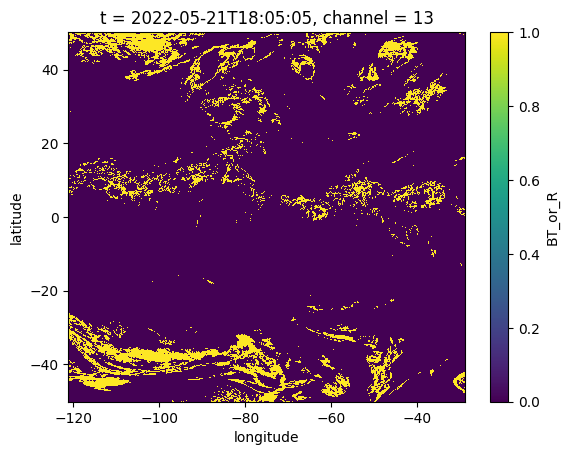

In [34]:
in_bin.sel(channel=13).plot()

In [30]:
ds.BT_or_R.max()

<xarray.DataArray 'BT_or_R' ()> Size: 8B
array(344.39335053)